## Aufgabe 1

In [35]:
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms as transforms
import torch
from PIL import Image
from pathlib import Path
import random

random.seed(20260217)

synset_words_file='/Users/luca/Projects/ms-data-science/deep-learning/hw5/imagenethelpercode/synset_words.txt'
imagenet_path = "/Users/luca/Projects/ms-data-science/deep-learning/hw5/imagenet-val"
imagenet_meta_path = "/Users/luca/Projects/ms-data-science/deep-learning/hw5/val"


In [27]:
weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()
model = resnet50(weights=weights)
model.eval();

In [3]:
import xml.etree.ElementTree as ET

def parsesynsetwords(filen):

  synsetstoclassdescriptions={}
  indicestosynsets={}
  synsetstoindices={}
  ct=-1
  with open(filen) as f:
    for line in f:
      if (len(line)> 5):
        z=line.strip().split()
        descr=''
        for i in range(1,len(z)):
          descr=descr+' '+z[i]
        
        ct+=1
        indicestosynsets[ct]=z[0]
        synsetstoindices[z[0]]=ct
        synsetstoclassdescriptions[z[0]]=descr[1:]
  return indicestosynsets,synsetstoindices,synsetstoclassdescriptions

def parseclasslabel(nm,synsetstoindices):  
  tree = ET.parse(nm)
  root = tree.getroot()

  lbset=set()
  
  for obj in root.findall('object'):
     for name in obj.findall('name'):
       #print name.text
       ind=synsetstoindices[name.text]
       firstname=name.text
       lbset.add(ind)
       
  if len(lbset)!=1:
    print     ('ERR: len(lbset)!=1',  len(lbset))
    exit()
    
  for s in lbset:
    label=  s
  return label,firstname

In [38]:
image1 = f"{imagenet_path}/n01601694/ILSVRC2012_val_00017028.JPEG"
metadata1 = f'{imagenet_meta_path}/ILSVRC2012_val_00017028.xml'

image2 = f"{imagenet_path}/n01534433/ILSVRC2012_val_00001915.JPEG"
metadata2 = f'{imagenet_meta_path}/ILSVRC2012_val_00001915.xml'

image3 = f"{imagenet_path}/n01843065/ILSVRC2012_val_00007284.JPEG"
metadata3 = f'{imagenet_meta_path}/ILSVRC2012_val_00007284.xml'

def predict_image(img_path, meta_path, preprocess=preprocess, print_log=False, crops=1):
  with Image.open(img_path) as img:
    # Apply inference preprocessing transforms
    batch = preprocess(img)
    
    if crops == 1:
      # Use the model and print the predicted category
      prediction = model(batch.unsqueeze(0)).squeeze(0).softmax(0)
      class_id = prediction.argmax().item()
      score = prediction[class_id].item()
      category_name = weights.meta["categories"][class_id]
    else:
      categories = []
      for i in range(0, crops):
        # Use the model and print the predicted category
        prediction = model(batch[i].unsqueeze(0)).squeeze(0).softmax(0)
        class_id = prediction.argmax().item()
        score = prediction[class_id].item()
        category_name = weights.meta["categories"][class_id]
        categories.append(category_name)
      category_name = max(categories, key=categories.count)

    # Print the actual class label
    indicestosynsets,synsetstoindices,synsetstoclassdescr=parsesynsetwords(synset_words_file)
    label,firstname=parseclasslabel(meta_path, synsetstoindices)
    if print_log:
      print("actual:", synsetstoclassdescr[indicestosynsets[label]], "\n")
      print(f"prediction: {category_name}: {100 * score:.1f}%")

    return category_name == synsetstoclassdescr[indicestosynsets[label]].split(", ")[0]

predict_image(image1, metadata1, print_log=True)
predict_image(image2, metadata2, print_log=True)
predict_image(image3, metadata3, print_log=True)

actual: water ouzel, dipper 

prediction: water ouzel: 31.0%
actual: junco, snowbird 

prediction: junco: 51.5%
actual: jacamar 

prediction: jacamar: 55.6%


True

In [5]:
image_files = list(Path(imagenet_path).glob("**/*.JPEG"))
image_files = random.sample(image_files, 500)
meta_files = [f"{imagenet_meta_path}/{img.stem}.xml" for img in image_files]

In [28]:
def calc_accuracy(preprocess=preprocess, crops=1):
    tp = 0.
    n = 0.

    errors = []

    for img, meta in zip(image_files, meta_files):
        try:
            tp+=1. if predict_image(img, meta, preprocess=preprocess, crops=crops) else 0.
            n +=1.
        except:
            errors.append(img)
    
    print(f"Unable to process {len(errors)} images")
    return tp/n

calc_accuracy(preprocess)

Unable to process 10 images


0.8

In [29]:
n = 380

new_preprocess = transforms.Compose([
    transforms.Resize(n + round(256/n)),
    transforms.CenterCrop(n),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

calc_accuracy(new_preprocess)

Unable to process 10 images


0.7755102040816326

In [20]:
n = 150

new_preprocess = transforms.Compose([
    transforms.Resize(n + round(256/n)),
    transforms.CenterCrop(n),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

calc_accuracy(new_preprocess)

0.7775510204081633

n=32: 0.1224
n=64: 0.4571
n=96: 0.6714
n=128: 0.7531
n=160: 0.7878
n=192: 0.7980
n=224: 0.7980
n=256: 0.8082
n=288: 0.8041
n=320: 0.8082


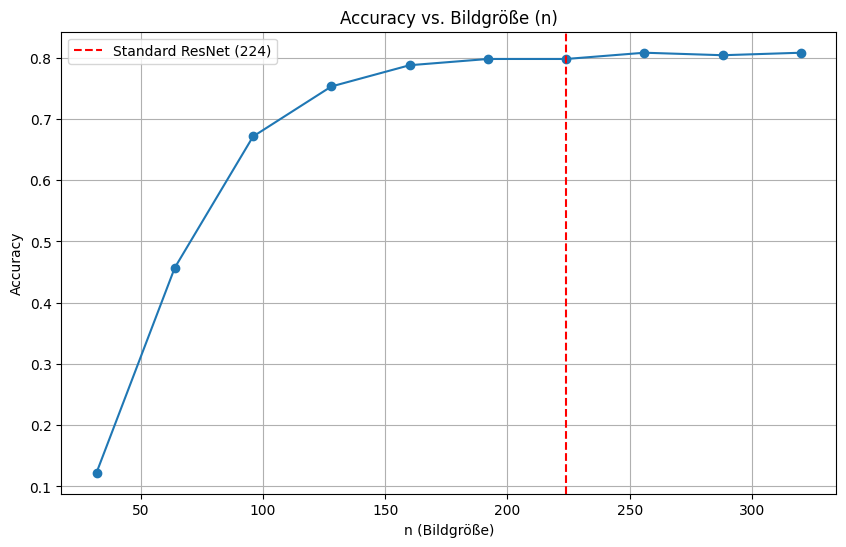

In [21]:
import matplotlib.pyplot as plt

n_values = [32, 64, 96, 128, 160, 192, 224, 256, 288, 320]
accuracies = []

for n in n_values:
    new_preprocess = transforms.Compose([
        transforms.Resize(n + round(256/n)),
        transforms.CenterCrop(n),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    acc = calc_accuracy(new_preprocess)
    accuracies.append(acc)
    print(f"n={n}: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_values, accuracies, marker='o')
plt.axvline(x=224, color='r', linestyle='--', label='Standard ResNet (224)')
plt.xlabel("n (Bildgröße)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Bildgröße (n)")
plt.legend()
plt.grid(True)
plt.show()

## Aufgabe 3

In [40]:
n = 224

new_preprocess = transforms.Compose([
    transforms.Resize(n + round(256/n)),
    transforms.FiveCrop(n),
    transforms.Lambda(lambda crops: torch.stack([
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(
        transforms.ToTensor()(crop)) for crop in crops
    ]))
])

calc_accuracy(preprocess=new_preprocess, crops=5)

Unable to process 10 images


0.810204081632653

In [41]:
n = 224

new_preprocess = transforms.Lambda(lambda img: torch.stack([
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(
    transforms.ToTensor()(
    transforms.RandomCrop(n)(
    transforms.Resize(n + round(256/n))(img)))) for _ in range(5)
]))

calc_accuracy(preprocess=new_preprocess, crops=5)

Unable to process 10 images


0.7918367346938775